IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# Projet final

<font size="+1" color="RED">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

*Double-cliquer ici et insérer les noms et prénoms de votre binôme*

In [2]:
"GURENKO Anastasiia"
"NOEL Jean-Paul"

'NOEL Jean-Paul'

Ce projet peut être fait en binôme ou tout seul.

**Le nom de chaque membre du binôme doit être indiqué dans la boîte ci-dessus**.


**Le compte-rendu est soumis sur la page Moodle.

Si vous êtes en binôme : **<u>un seul rendu doit être remis sur un seul des deux comptes du binôme</u>**.

Les groupes de plus de 2 personnes ne sont pas autorisés.

**La dernière séance de TD-TME11 de votre groupe sera réservée pour travailler sur ce mini-projet.**

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

**Nom à donner au fichier à poster** : *projet-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme

Voir ci-dessous ce qui est à remettre.



# Projet - mai 2026

<b>Date de remise du compte-rendu : <font size="+1" color="RED">au plus tard le lundi 1er juin 2026, avant 10h</font></b>.
    
<b>Attention!</b> le site Moodle ferme à 20h pile (heure du site Moodle)! prévoyez de vous y connecter au moins 15mn avant la fermeture...
<b>Il n'y aura pas de prolongation possible.</b>

## Travail à faire

Vous devez compléter ce notebook en rajoutant vos expérimentations avec vos algorithmes d'apprentissage (supervisé et non-supervisé) sur les données Fashion MNIST fournies (voir plus loin).

Vous devez appliquer les algorithmes d'apprentissage vus en cours et réaliser une analyse sur les données afin de mettre en évidence des résultats intéressants.

Les données seront chargées par les commandes de chargement des données fournies dans ce notebook (ci-dessous).
Dans le notebook que vous rendrez, le chargement des fichiers de données doit considérer cette arborescence.


## Remarque: utilisation d'IA générative 

Toute utilisation d'une IA générative (ChatGPT, Mistral, Claude,...) pour réaliser certains traitements de ce projet doit **obligatoirement** être indiqué dans votre notebook. De plus, si vous utilisez une telle IA générative, vous devez pouvoir être capable d'expliquer ce qu'elle vous a fourni et que vous avez utilisé.

## Compte-rendu demandé
Ce qui doit être remis avant la date limite : un unique fichier archive compressé (`.tgz`, ou `.zip` uniquement) de nom :
`projet-Nom1_Nom2.tgz` ou `projet-Nom1_Nom2.zip` contenant:
- ce **notebook** complété (et avec vos noms !). Il doit pouvoir être exécuté sans autre apport (pensez à vous en assurer avant de le rendre). 
- votre **librairie iads** complète, c'est à dire votre répertoire `iads/` contenant tous les fichiers python complets.
- un **poster** sous la forme d'un fichier PDF dont le nom est de la forme: *tme11-Nom1_Nom2.pdf* qui correspond à un poster décrivant l'ensemble des expérimentations menées et les résultats obtenus.


**Très important** : les fichiers dans l'archive doivent être placés de façon à respecter la structure de fichiers suivante :

          --projet-Nom1_Nom2/
              --iads/
                  -- Classifiers.py
                  -- etc.
              -- Projet/
                  --  projet-Nom1_Nom2.ipynb


<b>Remarque</b>: 
- **Les <u>fichiers de données ne doivent pas être inclus dans votre archive</u>** ! 
- Pensez à vérifier que votre archive contient bien tous les fichiers demandés et **seulement** les fichiers demandés.
- **Tous les fichiers demandés doivent être soumis avant la date limite**, en une seule archive comme indiqué ci-dessus.

## Soutenance des projets
**Les soutenances auront lieu le <font size="+1" color="RED">mardi 2 juin 2026</font>, à partir de 14h**. 

Un ordre de passage ainsi que la salle de TME où elles auront lieu seront affichées sur le Moodle la veille (la remise d'un compte-rendu à la date d'échéance indiquée (avant le lundi 1er juin 2026, 10h) est **obligatoire** pour passer une soutenance).

La <b>soutenance est obligatoire</b> : <u>tout projet pour lequel la soutenance n'est pas passée sera noté $0$</u>.

Modalités de la soutenance:
- durée de la soutenance : 10 mn pour un binôme, 7 mn pour un monôme ;
- elle a lieu devant un ordinateur avec le notebook et le poster comme support ;
    - elle commence par une rapide présentation des expérimentations réalisées et résultats obtenus (max. 4 à 5mns)
    - puis elle se poursuit par des questions posées individuellement aux membres du binômes sur les expériences ou le code python réalisé.
- la note de soutenance est individuelle pour chaque membre d'un binôme.



In [42]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random
from sklearn.decomposition import PCA
import graphviz as gv
%matplotlib inline  

import math
import time
import sys

# pour les dendrogrammes) :
import scipy

# --------------------------------
# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2
# --------------------------------


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering 
from iads import Clustering as clust

from iads import visualisation as vis

from iads import Arbres_decision as ar


## Données pour le projet : Fashion MNIST

Les données sont fournies dans l'archive `data.tgz`. 
Cette archive contient 2 fichiers CSV:
- le fichier `fashion-mnist_train.csv`: ce fichier doit servir à l'entraînement de vos modèles, et leur évaluation en validation croisée,
- le fichier `fashion-mnist_test.csv`: ce fichier ne doit être utilisé que pour évaluer un modèle et il ne doit pas servir pour faire mettre au point le modèle.


Une documentation sur ces données peut être consultée sur la <a href="https://fr.wikipedia.org/wiki/Fashion_MNIST" target="NEW">page wikipedia Fashion MNIST</a>.


#### Chargement des données

In [5]:
data_train = pd.read_csv('../data/fashion-mnist_train.csv')


In [6]:
data_test = pd.read_csv('../data/fashion-mnist_test.csv')
print(data_test['label'].unique())

[0 1 2 3 8 6 5 4 7 9]


In [7]:
data_train.shape

(60000, 785)

In [8]:
data_test.shape

(10000, 785)

## Tâches à réaliser

### Apprentissage supervisé

*Tâches*: évaluation d'algorithmes et de représentations des données.
- classification binaire
- classification multi-classe

*Etudes suggérées*:
- différents classifiers:
    - perceptron et variantes
    - k-plus proches voisins 
    - arbres de décision
    - ensembles de classifieurs
- analyse des résultats: comparaison des approches et de leurs hyper-paramètres
    - accuracy, temps d'exécutions
    - score fold par fold
    - matrice de confusion
    - ...


### Apprentissage non-supervisé

*Tâche*: présence éventuelle de groupes de données: groupes intra-classes, et/ou groupes interclasses.

*Etudes possibles*:
- étudier l'application d'un clustering hiérarchique et son résultat;
- étudier les résultats de l'application de l'algorithme des k-moyennes, pour différentes valeurs de k: roposer des évaluations des clusters trouvés afin de mettre en évidence les plus intéressants:
    - en utilisant les indices d'évaluation présentés en cours;
    - en comparant par diverses méthodes les clusters trouvés avec les vrais labels des classes (targets y).
- proposer une visualisation des résultats obtenus
- analyse des exemples mal-classés: est-ce qu'ils forment un (ou des) sous-groupes?
- ...


   


## Poster à rendre dans le compte-rendu (format PDF)

Votre poster doit décrire de façon synthétique **l'ensemble des expérimentations** menées sur les données, les résultats obtenus en apprentissage supervisé et en apprentissage non-supervisé ainsi que les conclusions/bilans que vous tirez de ces expérimentations (ie. ce que vous avez appris sur ces données).

**Important*: vous devez indiquer vos noms/prénoms sur le poster.


# Votre travail commence à partir d'ici 

## Introduction : Présentation des Classifieurs

1. ClassifierKNN (K-Plus Proches Voisins)
- Principe : C'est un algorithme d'apprentissage "paresseux" (lazy learning). 
Il n'y a pas de phase d'entraînement à proprement parler : la méthode 
train se contente de stocker le dataset en mémoire.
- Algorithme : Pour prédire la classe d'une nouvelle image x, le modèle 
calcule la distance euclidienne entre x et tous les exemples stockés. 
Il sélectionne les K exemples les plus proches et effectue un vote 
majoritaire.
- Complexité et limites : La phase de prédiction est extrêmement lourde 
(O(N * d) où N est le nombre d'images et d la dimension). 

2. ClassifierPerceptron (Perceptron de Rosenblatt)
- Principe : C'est un modèle linéaire itératif et online. 
Il cherche à trouver un hyperplan (un vecteur de poids w) capable 
de séparer les classes dans l'espace originel.
- Algorithme : À chaque itération (train_step), il parcourt les données 
dans un ordre aléatoire. S'il fait une mauvaise prédiction sur un 
exemple, il ajuste immédiatement ses poids 
- Limites : Le perceptron classique ne converge que si les données sont 
linéairement séparables. Sur des images de vêtements complexes, 
les classes se chevauchent fortement, ce qui provoque une instabilité 
des poids en fin d'apprentissage.

3. ClassifierPerceptronBias (Perceptron avec Biais)
- Principe : C'est une extension directe du Perceptron classique qui 
introduit un terme de biais explicite dans le modèle.
- Algorithme : Le vecteur d'entrée x est augmenté d'une constante -1 
(via la méthode augmente), ce qui permet au modèle d'apprendre 
un hyperplan qui ne passe pas nécessairement par l'origine. 
Concrètement, le vecteur de poids interne est de dimension d+1, 
où le dernier poids joue le rôle du biais.
- Avantage : Sans biais, l'hyperplan est contraint de passer par 
l'origine, ce qui limite fortement la capacité du modèle. 
Le biais libère cette contrainte et améliore la flexibilité 
de la frontière de décision.

4. ClassifierPerceptronStable (Pocket Algorithm)
- Principe : C'est une amélioration directe du Perceptron classique 
pour les cas non-linéairement séparables (comme Fashion MNIST).
- Algorithme : Il introduit une variable "poche" (pocket) qui garde en 
mémoire la meilleure configuration du vecteur de poids w (celle qui 
donne la plus haute accuracy sur le train set) observée depuis le début 
du cycle. Même si le modèle diverge ou oscille à la dernière époque, 
il restitue à la fin les meilleurs poids historiques.
- Attente : Ce modèle devrait offrir de bien meilleures performances 
et une plus grande robustesse que le perceptron classique.

5. ClassifierPerceptronKernel (Perceptron Noyauté)
- Principe : Les frontières linéaires sont souvent insuffisantes pour 
des images complexes. Le Perceptron Kernelisé utilise le "Kernel Trick" 
(astuce du noyau).
- Algorithme : Grâce à un objet Noyau (Kernel), les données sont 
projetées implicitement dans un espace de dimension supérieure 
(parfois infinie) où elles deviennent linéairement séparables. 
Le produit scalaire standard est remplacé par une fonction de noyau 
(par exemple, un noyau polynomial ou RBF). Dans notre cas, KernelPoly 
projette 2 dimensions vers 6 features polynomiales (1, x1, x2, x1², x2², x1·x2),
permettant des frontières de décision courbes.

6. ClassifierMultiOAA (One-Against-All)
- Principe : Tous les classifieurs précédents (Perceptron) sont 
intrinsèquement binaires. Fashion MNIST 
contient 10 classes. Cet algorithme sert de pont pour passer du 
binaire au multiclasse.
- Algorithme : Pour C classes (ici C=10), il entraîne C
 sous-classifieurs binaires indépendants. Le classifieur numéro i
   apprend à distinguer la classe i (label +1) de toutes les autres 
   classes combinées (label -1). Lors de la prédiction, on soumet 
   l'image aux 10 classifieurs, et on retient la classe dont 
   le modèle renvoie le score le plus élevé.

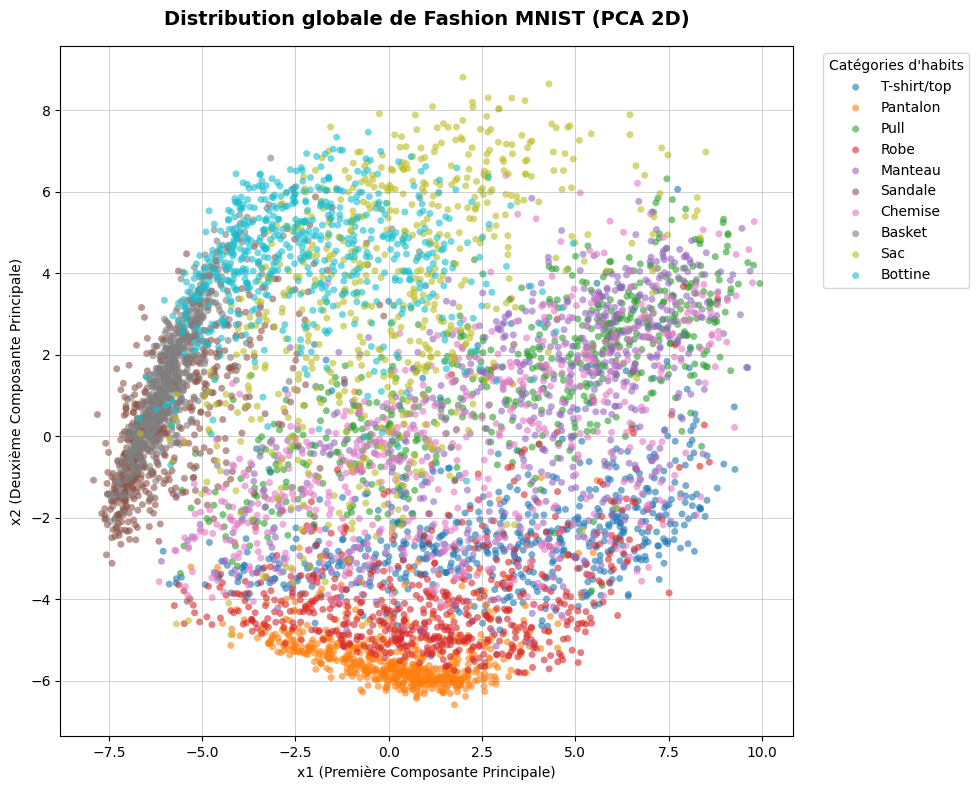

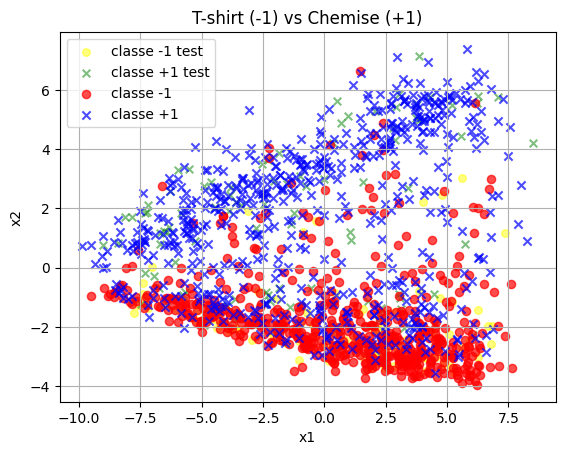

In [68]:
"""
PREMIER ETAPE: Visualisation des données
"""

Y_train_all = data_train['label'].to_numpy()
Y_test_all  = data_test['label'].to_numpy()

X_train_all = data_train.drop(columns=['label']).to_numpy() / 255.0
X_test_all  = data_test.drop(columns=['label']).to_numpy() / 255.0

X_knn, Y_knn = ut.echantillonnage_homogene(X_train_all, Y_train_all, proportion=0.02)
X_sub, Y_sub = ut.echantillonnage_homogene(X_train_all, Y_train_all, proportion=0.10)

vis.plot_all_fashion_2d(X_sub, Y_sub)

# --- Filtrage binaire (classes 0 et 6) ---
train_mask = (data_train['label'] == 0) | (data_train['label'] == 6)
test_mask  = (data_test['label']  == 0) | (data_test['label']  == 6)

X_train_pixels = data_train.loc[train_mask].drop(columns=['label']).to_numpy() / 255.0
Y_train_pixels = data_train.loc[train_mask, 'label'].to_numpy() 

X_test_pixels  = data_test.loc[test_mask].drop(columns=['label']).to_numpy() / 255.0
Y_test_pixels  = data_test.loc[test_mask, 'label'].to_numpy()  

# --- Pour la visualisation PCA ---
X_te_sampled, Y_te_sampled = ut.echantillonnage_homogene(X_test_pixels,  Y_test_pixels,  proportion=0.10)
X_tr_sampled, Y_tr_sampled = ut.echantillonnage_homogene(X_train_pixels, Y_train_pixels, proportion=0.10)

Y_te_sampled = np.where(Y_te_sampled == 0, -1, 1)
Y_tr_sampled = np.where(Y_tr_sampled == 0, -1, 1)

pca_2d = PCA(n_components=2)
X_tr_sampled_pca = pca_2d.fit_transform(X_tr_sampled)
X_te_sampled_pca = pca_2d.transform(X_te_sampled)

vis.plot2DTrainTestSet(X_tr_sampled_pca, Y_tr_sampled, X_te_sampled_pca, Y_te_sampled,
                       nom_dataset="T-shirt (-1) vs Chemise (+1)")

# --- Variables globales pour les cellules suivantes ---
X_train_raw = X_train_all
Y_train_raw = Y_train_all
X_test_raw  = X_test_all
Y_test_raw  = Y_test_all

#### 1. L'Accuracy (Taux de bonne prédiction)

L'Accuracy est la métrique globale la plus intuitive. Elle représente 
mathématiquement le ratio entre le nombre de prédictions correctes 
et le nombre total d'exemples dans le jeu de données :

Accuracy = Prédictions Correctes / Total des exemples

Limitation: Bien qu'efficace sur des classes équilibrées, 
l'accuracy ne permet pas de voir comment le modèle se trompe 
(par exemple, s'il confond systématiquement les chemises avec les 
t-shirts ou l'inverse).


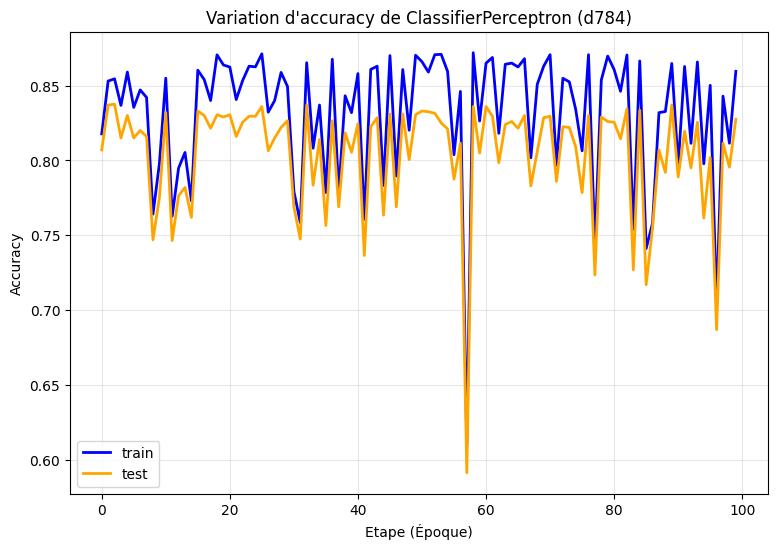

Accuracy finale (train):  0.8595
Accuracy finale (test) :  0.8275


In [71]:
"""
DEUXIEME ETAPE: Evaluation des classifiers binaires via accuracy
"""
np.random.seed(42)
learning_rate = 0.01

n_features = X_train_pixels.shape[1]
perseptron = cl.ClassifierPerceptron(n_features, learning_rate, True, False)
perseptron._rng = np.random.default_rng(seed=42)

train_acc = []
test_acc  = []

Y_train_bin = np.where(Y_train_pixels == 0, -1, 1)
Y_test_bin  = np.where(Y_test_pixels  == 0, -1, 1)

N = 100
for i in range(N):
    perseptron.train_step(X_train_pixels, Y_train_bin)

    train_acc.append(perseptron.accuracy(X_train_pixels, Y_train_bin))
    test_acc.append(perseptron.accuracy(X_test_pixels,   Y_test_bin))

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy de {perseptron}")
courbe_train = plt.plot(train_acc, label='train', color='blue',   linewidth=2)
courbe_test  = plt.plot(test_acc,  label='test',  color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy finale (train): ", train_acc[-1])
print("Accuracy finale (test) : ", test_acc[-1])

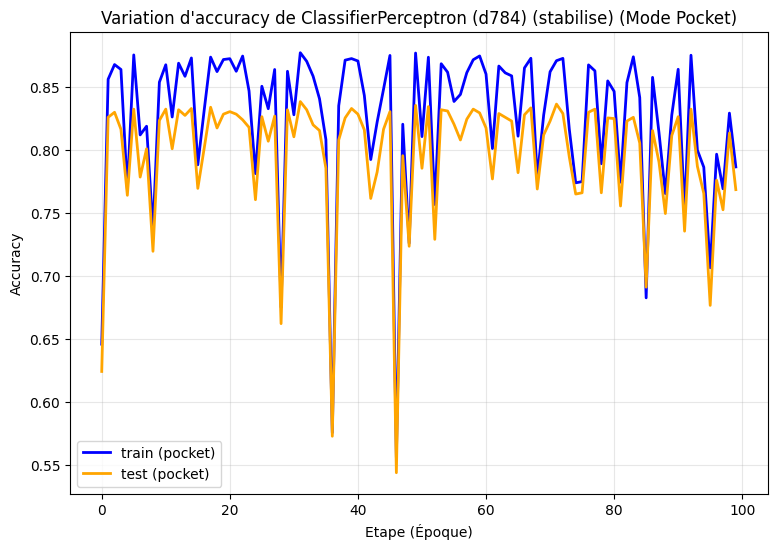

Accuracy finale STABLE (train):  0.7865833333333333
Accuracy finale STABLE (test) :  0.7685


In [73]:
"""
DEUXIEME ETAPE: Evaluation des classifiers binaires via accuracy (STABLE VIA .train)
"""
np.random.seed(42)
learning_rate = 0.01

n_features = X_train_pixels.shape[1]
perseptron_stable = cl.ClassifierPerceptronStable(n_features, learning_rate, True, False)
perseptron_stable._rng = np.random.default_rng(seed=42)

train_acc = []
test_acc = []

Y_train_bin = np.where(Y_train_pixels == 0, -1, 1)
Y_test_bin  = np.where(Y_test_pixels  == 0, -1, 1)

N = 100
for i in range(N):
    perseptron.train_step(X_train_pixels, Y_train_bin)

    train_acc.append(perseptron.accuracy(X_train_pixels, Y_train_bin))
    test_acc.append(perseptron.accuracy(X_test_pixels,   Y_test_bin))

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy de {perseptron_stable} (Mode Pocket)")
courbe_train = plt.plot(train_acc, label='train (pocket)', color='blue', linewidth=2)
courbe_test = plt.plot(test_acc, label='test (pocket)', color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy finale STABLE (train): ", train_acc[-1])
print("Accuracy finale STABLE (test) : ", test_acc[-1])

K = 1 | Train: 1.0000 | Test: 0.7850
K = 3 | Train: 0.9025 | Test: 0.8200
K = 5 | Train: 0.8817 | Test: 0.8250
K = 7 | Train: 0.8742 | Test: 0.8350
K = 9 | Train: 0.8575 | Test: 0.8200
K = 11 | Train: 0.8583 | Test: 0.8150
K = 15 | Train: 0.8525 | Test: 0.8400
K = 21 | Train: 0.8483 | Test: 0.8550


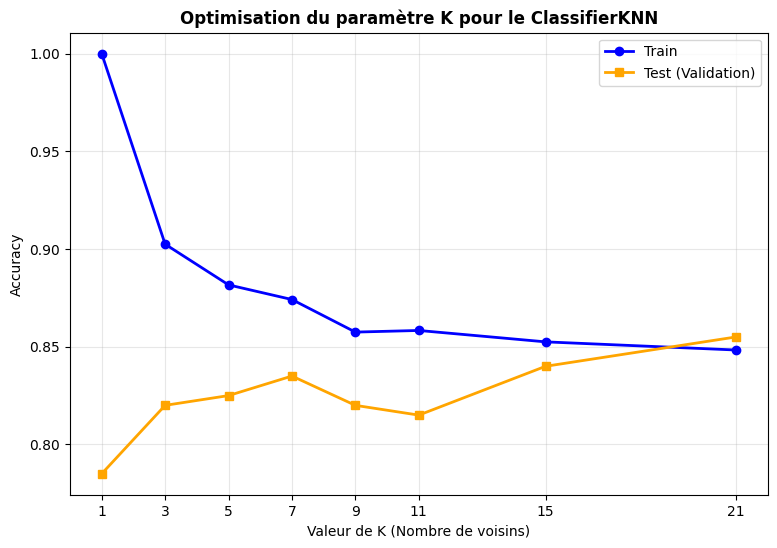

In [75]:
"""
DEUXIEME ETAPE: Evaluation du classifier KNN via le choix du K
"""
np.random.seed(42)

# ✅ Y_train_pixels вместо Y_train_raw
X_knn_train, Y_knn_train_raw = ut.echantillonnage_homogene(X_train_pixels, Y_train_pixels, proportion=0.10)
Y_knn_train_bin = np.where(Y_knn_train_raw == 0, -1, 1)

# ✅ Y_test_pixels вместо Y_test_raw_bin
Y_test_bin  = np.where(Y_test_pixels == 0, -1, 1)
X_knn_test  = X_test_pixels[:200]
Y_knn_test_bin = Y_test_bin[:200]

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_train_acc = []
knn_test_acc  = []

n_features = X_knn_train.shape[1]

for k in k_values:
    knn_clf = cl.ClassifierKNN(n_features, k)
    knn_clf.train(X_knn_train, Y_knn_train_bin)

    acc_tr = knn_clf.accuracy(X_knn_train, Y_knn_train_bin)
    acc_te = knn_clf.accuracy(X_knn_test,  Y_knn_test_bin)

    knn_train_acc.append(acc_tr)
    knn_test_acc.append(acc_te)
    print(f"K = {k} | Train: {acc_tr:.4f} | Test: {acc_te:.4f}")

plt.figure(figsize=(9, 6))
plt.plot(k_values, knn_train_acc, label='Train',             color='blue',   marker='o', linewidth=2)
plt.plot(k_values, knn_test_acc,  label='Test (Validation)', color='orange', marker='s', linewidth=2)

plt.title("Optimisation du paramètre K pour le ClassifierKNN", fontsize=12, fontweight='bold')
plt.xlabel("Valeur de K (Nombre de voisins)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

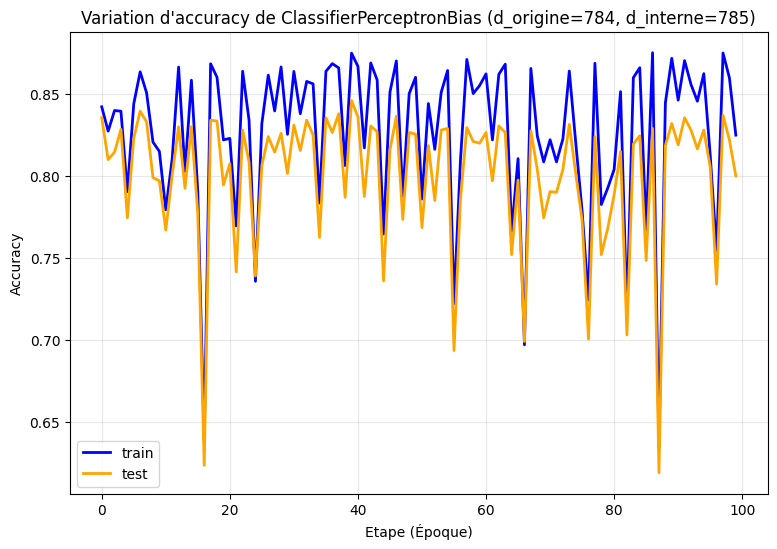

Accuracy finale (train):  0.8249166666666666
Accuracy finale (test) :  0.8


In [77]:
"""
DEUXIEME ETAPE: Evaluation des classifiers binaires via accuracy Perceptron avec Bias
"""
np.random.seed(42)
learning_rate = 0.01

n_features = X_train_pixels.shape[1]
perseptron_bias = cl.ClassifierPerceptronBias(n_features, learning_rate, True, False)
perseptron_bias._rng = np.random.default_rng(seed=42)

train_acc = []
test_acc  = []

Y_train_bin = np.where(Y_train_pixels == 0, -1, 1)
Y_test_bin  = np.where(Y_test_pixels  == 0, -1, 1)

N = 100
for i in range(N):
    perseptron_bias.train_step(X_train_pixels, Y_train_bin)

    train_acc.append(perseptron_bias.accuracy(X_train_pixels, Y_train_bin))
    test_acc.append(perseptron_bias.accuracy(X_test_pixels,   Y_test_bin))

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy de {perseptron_bias}")
courbe_train = plt.plot(train_acc, label='train', color='blue',   linewidth=2)
courbe_test  = plt.plot(test_acc,  label='test',  color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy finale (train): ", train_acc[-1])
print("Accuracy finale (test) : ", test_acc[-1])

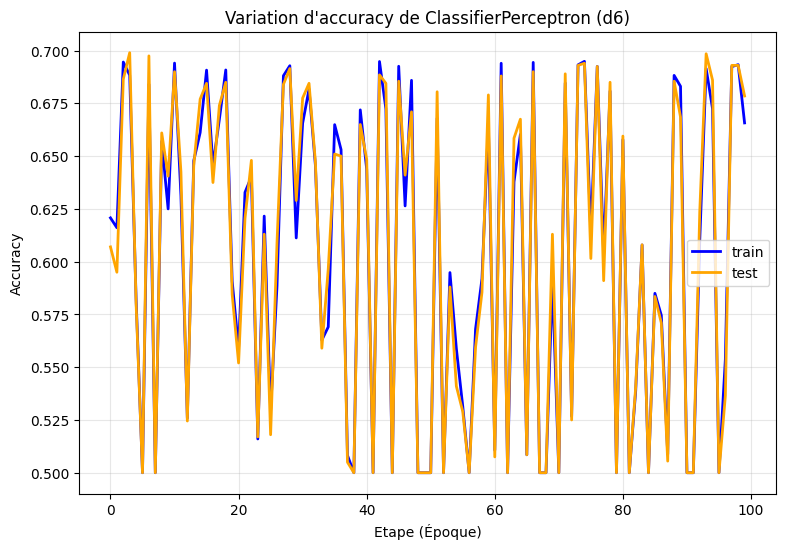

Accuracy finale KERNEL (train):  0.66575
Accuracy finale KERNEL (test) :  0.6785


In [78]:
"""
DEUXIEME ETAPE: Evaluation le classifier ClassifierPerceptronKernel via accuracy
"""
np.random.seed(42)
learning_rate = 0.01

X_train_2D = X_train_pixels[:, [200, 400]]
X_test_2D  = X_test_pixels[:, [200, 400]]

train_mask = (data_train['label'] == 0) | (data_train['label'] == 6)
test_mask  = (data_test['label']  == 0) | (data_test['label']  == 6)

Y_train_bin = np.where(data_train.loc[train_mask, 'label'].to_numpy() == 0, -1, 1)
Y_test_bin  = np.where(data_test.loc[test_mask,   'label'].to_numpy() == 0, -1, 1)

un_noyau = cl.KernelPoly()
perseptron_kernel = cl.ClassifierPerceptronKernel(2, learning_rate, un_noyau, True, False)
perseptron_kernel._rng = np.random.default_rng(seed=42)

train_acc = []
test_acc  = []

N = 100
for i in range(N):
    perseptron_kernel.train(X_train_2D, Y_train_bin, nb_max=1)
    
    train_acc.append(perseptron_kernel.accuracy(X_train_2D, Y_train_bin))
    test_acc.append(perseptron_kernel.accuracy(X_test_2D,   Y_test_bin))

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy de {perseptron_kernel}")
courbe_train = plt.plot(train_acc, label='train', color='blue',   linewidth=2)
courbe_test  = plt.plot(test_acc,  label='test',  color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy finale KERNEL (train): ", train_acc[-1])
print("Accuracy finale KERNEL (test) : ", test_acc[-1])

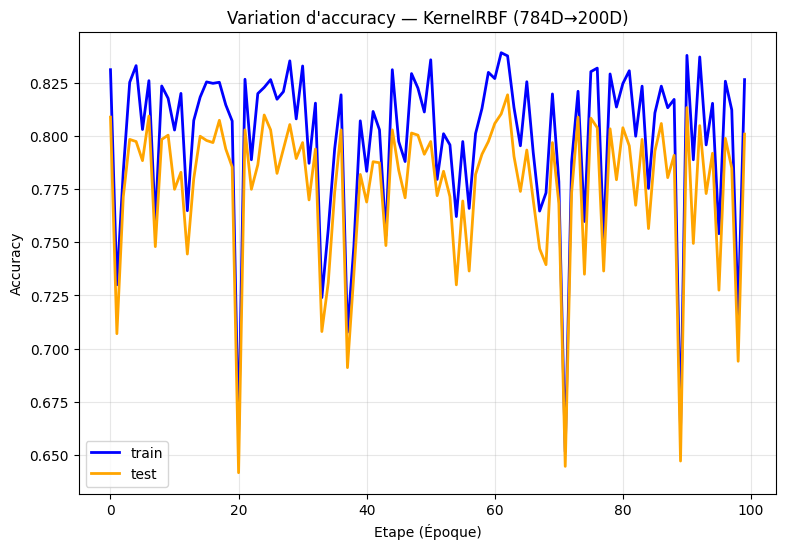

Accuracy finale RBF (train): 0.8267
Accuracy finale RBF (test) : 0.8010


In [79]:
"""
ClassifierPerceptronKernel avec KernelRBF (784D -> 200D)
"""
np.random.seed(42)
learning_rate = 0.01

train_mask = (data_train['label'] == 0) | (data_train['label'] == 6)
test_mask  = (data_test['label']  == 0) | (data_test['label']  == 6)

Y_train_bin = np.where(data_train.loc[train_mask, 'label'].to_numpy() == 0, -1, 1)
Y_test_bin  = np.where(data_test.loc[test_mask,   'label'].to_numpy() == 0, -1, 1)

dim_in  = X_train_pixels.shape[1] 
dim_out = 200                   

un_noyau_rbf = cl.KernelRBF(dim_in, dim_out, gamma=0.01, seed=42)
perseptron_rbf = cl.ClassifierPerceptronKernel(dim_in, learning_rate, un_noyau_rbf, True, False)
perseptron_rbf._rng = np.random.default_rng(seed=42)

train_acc = []
test_acc  = []

N = 100
for i in range(N):
    perseptron_rbf.train(X_train_pixels, Y_train_bin, nb_max=1)
    
    train_acc.append(perseptron_rbf.accuracy(X_train_pixels, Y_train_bin))
    test_acc.append(perseptron_rbf.accuracy(X_test_pixels,   Y_test_bin))

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy — KernelRBF (784D→{dim_out}D)")
courbe_train = plt.plot(train_acc, label='train', color='blue',   linewidth=2)
courbe_test  = plt.plot(test_acc,  label='test',  color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Accuracy finale RBF (train): {train_acc[-1]:.4f}")
print(f"Accuracy finale RBF (test) : {test_acc[-1]:.4f}")

#### La Matrice de Confusion (Une analyse plus fine) 
Pour dépasser les limites de l'accuracy, la Matrice de Confusion est 
l'outil idéal. Elle permet de cartographier précisément le comportement 
du classifieur en croisant ses prédictions avec les vrais labels du jeu 
de données. 

Dans notre cas binaire (T-shirt vs Chemise), elle classe les résultats 
en 4 zones :
* Vrais Négatifs (VN): Les T-shirts correctement prédits comme T-shirts.
* Vrais Positifs (VP): Les Chemises correctement prédites comme Chemises.
* Faux Positifs (FP): Les T-shirts que le modèle a confondus avec 
    des Chemises.
* Faux Négatifs (FN): Les Chemises que le modèle a confondus avec des 
    T-shirts.

Intérêt majeur :** Elle permet d'identifier visuellement si le modèle 
souffre d'un biais asymétrique (par exemple, s'il est excellent pour 
reconnaître les t-shirts mais complètement aveugle face aux chemises).

1. MATRICE DE CONFUSION : KNN (K=21)
[-1  1]


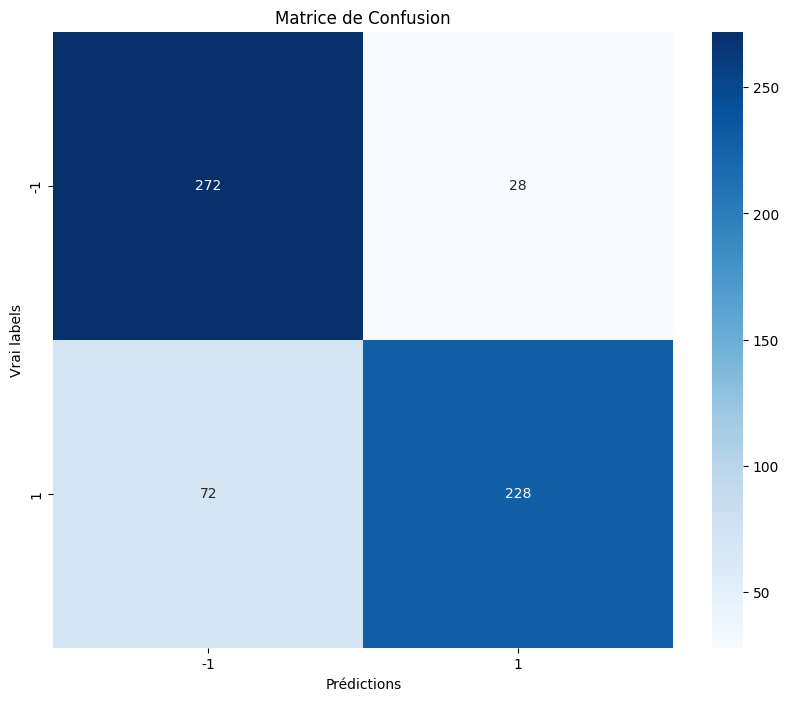

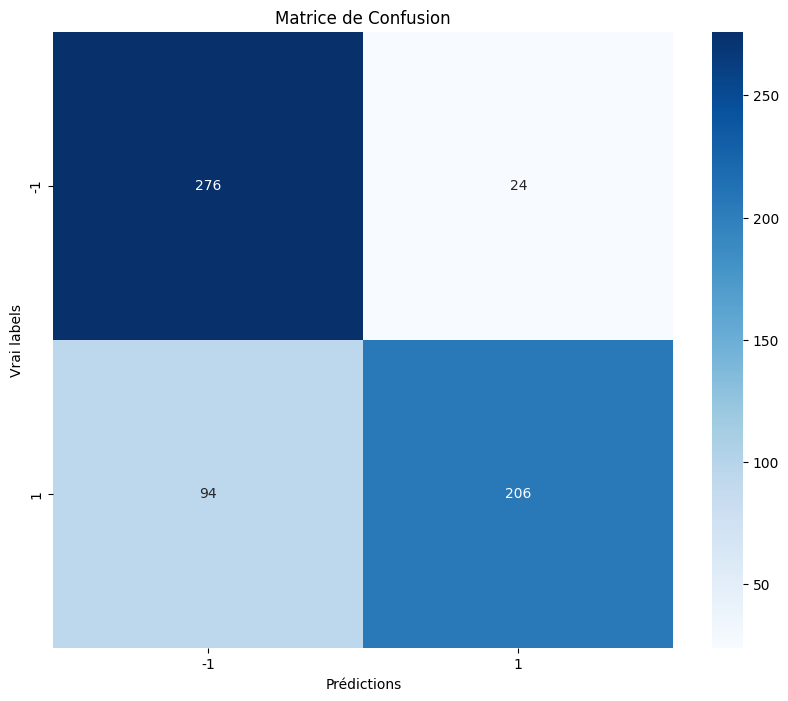

2. MATRICE DE CONFUSION : PERCEPTRON CLASSIQUE
[-1  1]


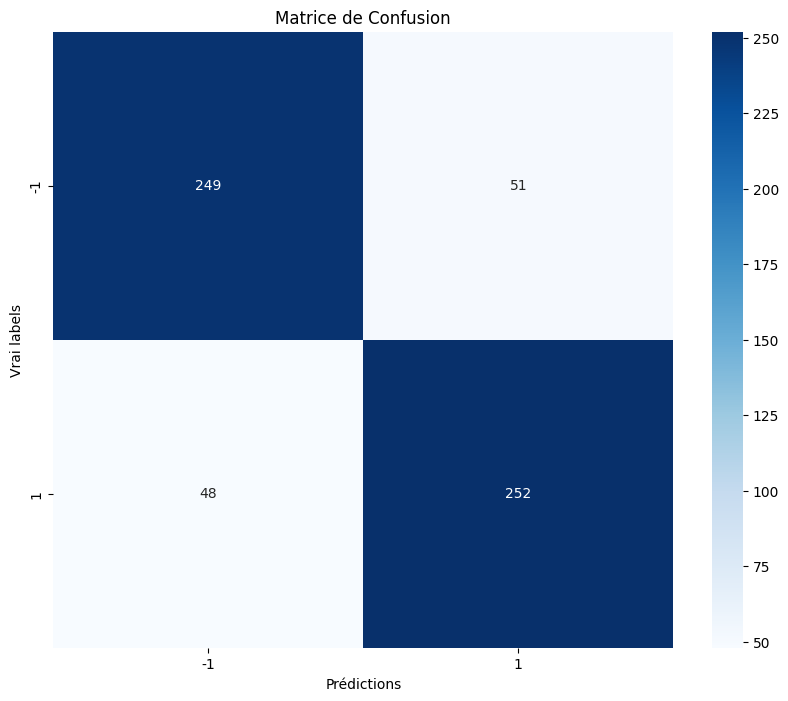

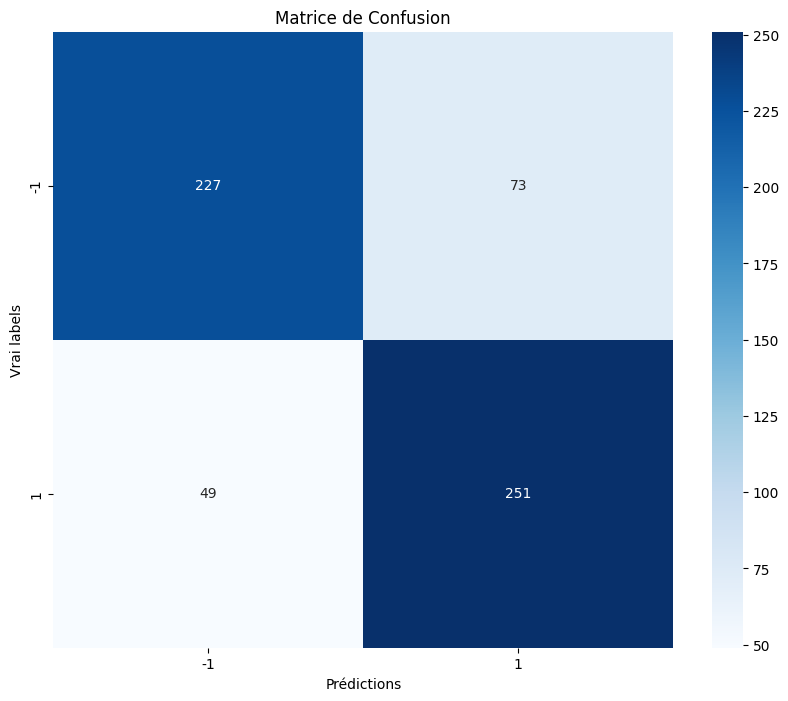

3. MATRICE DE CONFUSION : PERCEPTRON STABLE (POCKET)
[-1  1]


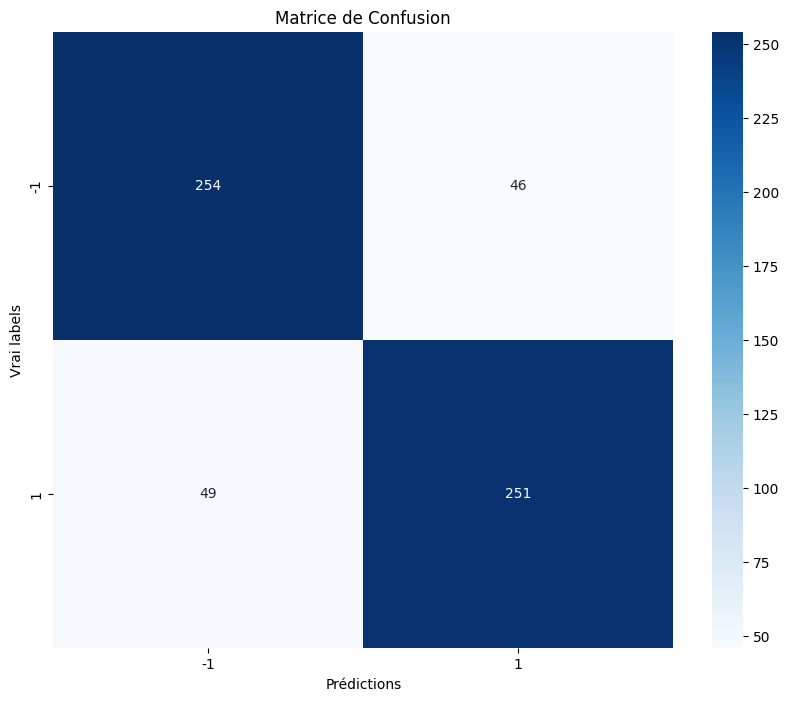

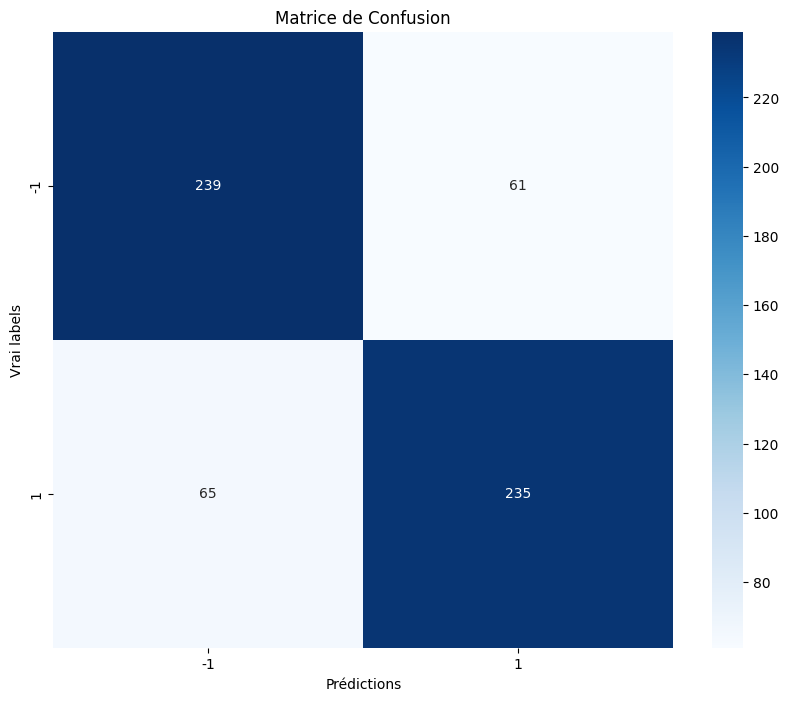

4. MATRICE DE CONFUSION : PERCEPTRON AVEC BIAS
[-1  1]


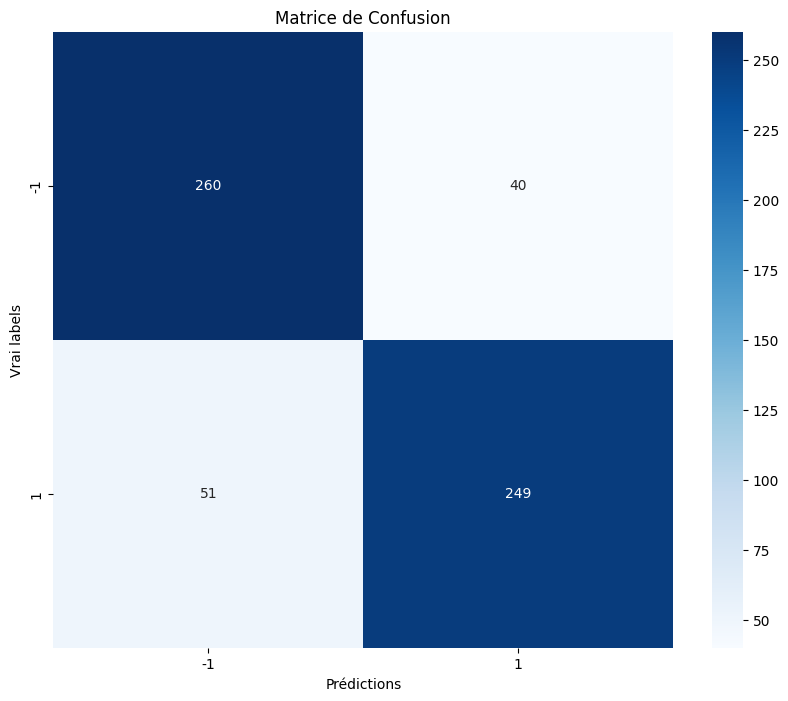

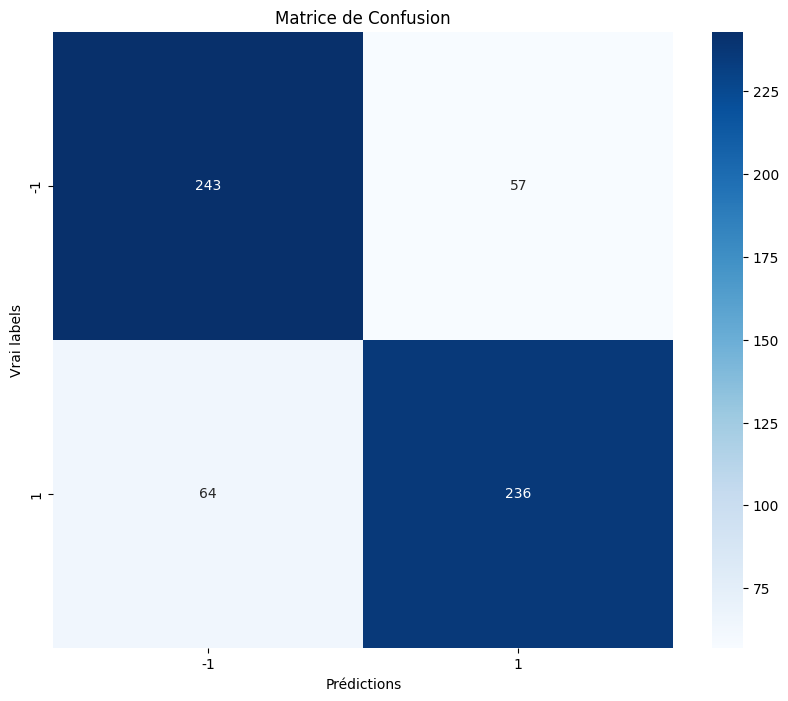

5. MATRICE DE CONFUSION : PERCEPTRON AVEC KERNELISATION (2D)
[-1  1]


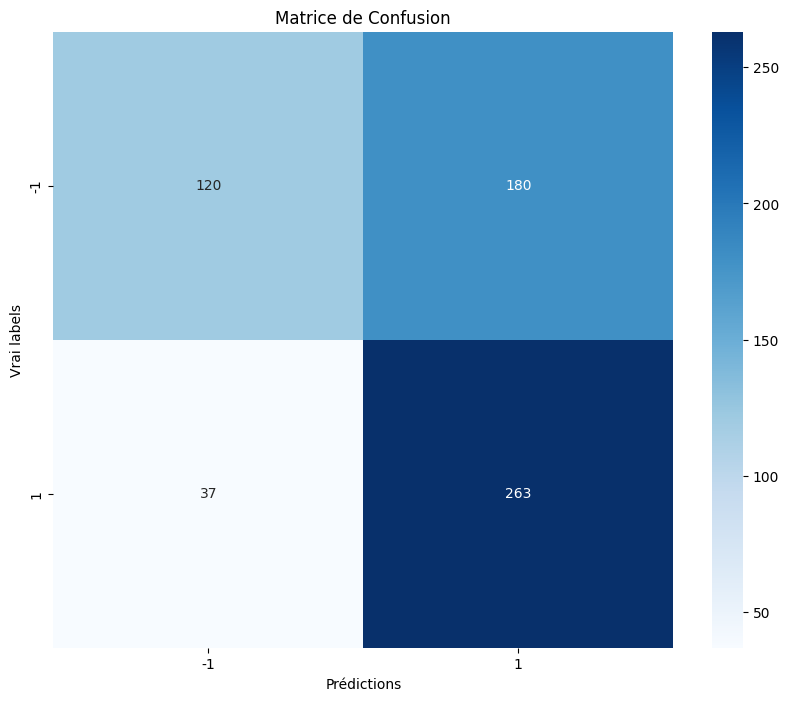

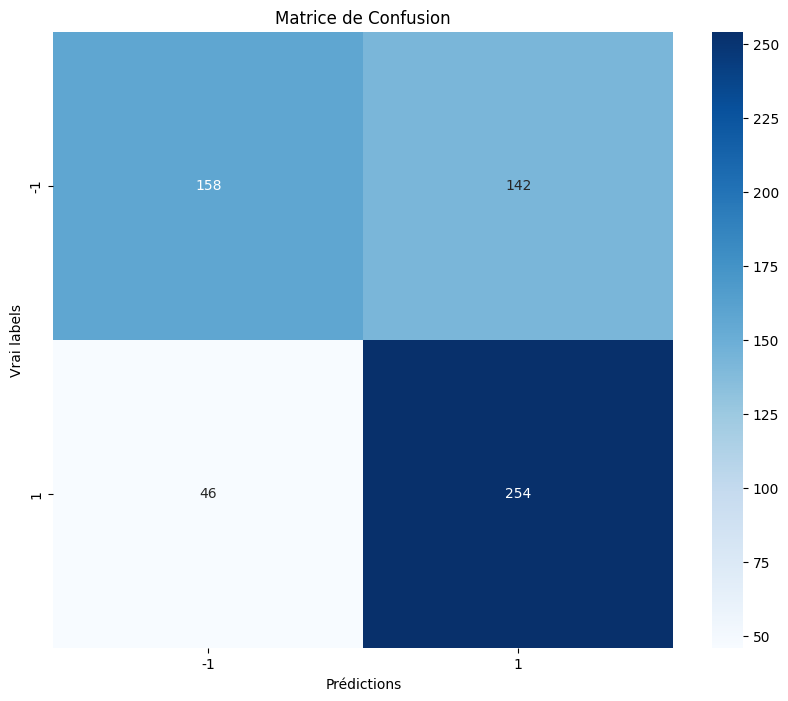

In [81]:
"""
DEUXIEME ETAPE: Matrices de confusion pour les 5 modèles (100% Fixé et Déterministe)
"""
np.random.seed(42)

choix_label_1, choix_label_2 = 0, 6
labels_to_keep = [choix_label_1, choix_label_2]

data_train_binaire = data_train[data_train['label'].isin(labels_to_keep)].copy()
data_train_binaire['label'] = data_train_binaire['label'].replace({choix_label_1: -1, choix_label_2: 1})

X_bi = data_train_binaire.drop(columns=['label']).values
Y_bi = data_train_binaire['label'].values

if X_bi.max() > 1.0:
    X_bi = X_bi / 255.0

X_small, Y_small = ut.echantillonnage_homogene(X_bi, Y_bi, 0.1)
DS_binaire = (X_small, Y_small)

n_features = X_small.shape[1]  

X_bi_2D = data_train_binaire.drop(columns=['label']).values[:, [200, 400]]
Y_bi_2D = data_train_binaire['label'].values

if X_bi_2D.max() > 1.0:
    X_bi_2D = X_bi_2D / 255.0

X_small_2D, Y_small_2D = ut.echantillonnage_homogene(X_bi_2D, Y_bi_2D, 0.1)
DS_binaire_2D = (X_small_2D, Y_small_2D)

un_noyau = cl.KernelPoly()

perseptron_kernel = cl.ClassifierPerceptronKernel(2, learning_rate, un_noyau, False, False)
perceptron_cl = cl.ClassifierPerceptron(n_features, learning_rate=0.01, init=True)
perceptron_st = cl.ClassifierPerceptronStable(n_features, learning_rate=0.01, init=True)
knn_clf = cl.ClassifierKNN(n_features, k=21)
perseptron_bias = cl.ClassifierPerceptronBias(n_features, learning_rate=0.01, init=True)

perceptron_cl._rng = np.random.default_rng(seed=42)
perceptron_st._rng = np.random.default_rng(seed=42)
perseptron_bias._rng = np.random.default_rng(seed=42)
perseptron_kernel._rng = np.random.default_rng(seed=42)


print("="*60)
print("1. MATRICE DE CONFUSION : KNN (K=21)")
print("="*60)
ev.matrice_de_confusion(knn_clf, DS_binaire, nb_iter=2, stratified=True)

print("="*60)
print("2. MATRICE DE CONFUSION : PERCEPTRON CLASSIQUE")
print("="*60)
ev.matrice_de_confusion(perceptron_cl, DS_binaire, nb_iter=2, stratified=True)

print("="*60)
print("3. MATRICE DE CONFUSION : PERCEPTRON STABLE (POCKET)")
print("="*60)
ev.matrice_de_confusion(perceptron_st, DS_binaire, nb_iter=2, stratified=True)

print("="*60)
print("4. MATRICE DE CONFUSION : PERCEPTRON AVEC BIAS")
print("="*60)
ev.matrice_de_confusion(perseptron_bias, DS_binaire, nb_iter=2, stratified=True)

print("="*60)
print("5. MATRICE DE CONFUSION : PERCEPTRON AVEC KERNELISATION (2D)")
print("="*60)
ev.matrice_de_confusion(perseptron_kernel, DS_binaire_2D, nb_iter=2, stratified=True)

#### 3. La Validation Croisée (K-Fold Cross-Validation)

Principe Théorique
Évaluer un modèle sur un seul découpage fixe (Train/Test) introduit 
un biais de sélection lié au hasard. Pour obtenir une mesure 
objective et stable, on utilise la Validation Croisée Stratifiée:
1. Partitionnement: Le dataset est divisé en $K$ blocs égaux (ici, K=4).
2. Stratification: Chaque bloc préserve strictement la proportion 
    initiale des classes (50% T-shirts, 50% Chemises).
3. Processus cyclique: Le modèle est entraîné $K$ fois. 
    À chaque itération, un bloc différent sert de jeu de test, 
    et les K-1 autres servent de jeu d'apprentissage.

Métriques de performance
La fonction calcule ensuite deux indicateurs fondamentaux :
*La Moyenne: Représente l'accuracy réelle globale du classifieur 
    (la performance attendue).
*L'Écart-type (sigma):Mesure la stabilité de l'algorithme. 
    Un écart-type proche de 0 indique un modèle robuste, tandis qu'un 
    écart-type élevé révèle une forte sensibilité aux variations des 
    données.

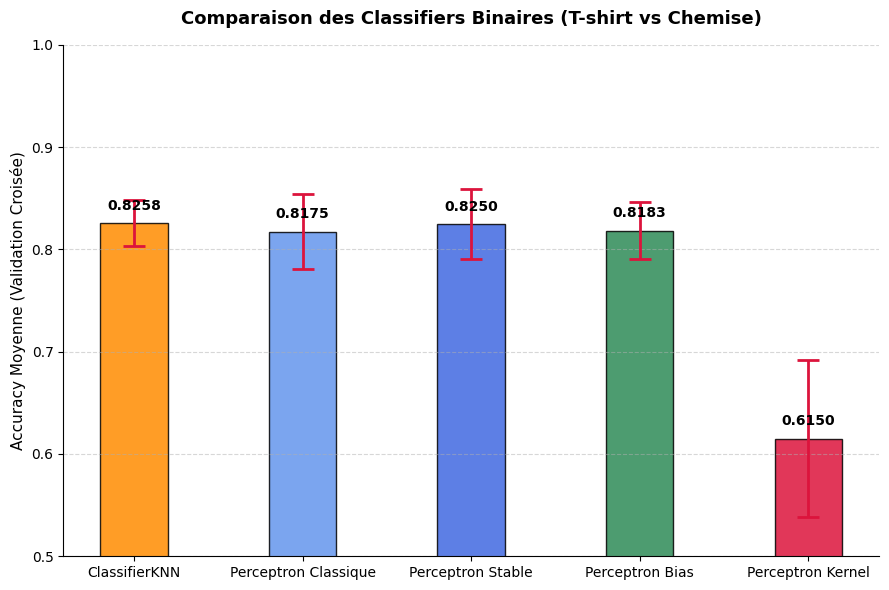

In [82]:
"""
DEUXIEME ETAPE: Validation Croisée Globale (Version avec fonction graphique)
"""
np.random.seed(42)
_, moy_knn, std_knn = ev.validation_croisee(knn_clf, DS_binaire, nb_iter=4, stratified=True)
_, moy_per, std_per = ev.validation_croisee(perceptron_cl, DS_binaire, nb_iter=4, stratified=True)
_, moy_st, std_st = ev.validation_croisee(perceptron_st, DS_binaire, nb_iter=4, stratified=True)
_, moy_b, std_b = ev.validation_croisee(perseptron_bias, DS_binaire, nb_iter=4, stratified=True)
_, moy_k, std_k = ev.validation_croisee(perseptron_kernel, DS_binaire_2D, nb_iter=4, stratified=True)

noms = ['ClassifierKNN', 'Perceptron Classique', 'Perceptron Stable', 'Perceptron Bias', 'Perceptron Kernel']
moyennes = [moy_knn, moy_per, moy_st, moy_b, moy_k]
ecarts_types = [std_knn, std_per, std_st, std_b, std_k]

vis.plot_comparaison_classifiers(noms, moyennes, ecarts_types, 
                             title="Comparaison des Classifiers Binaires (T-shirt vs Chemise)")

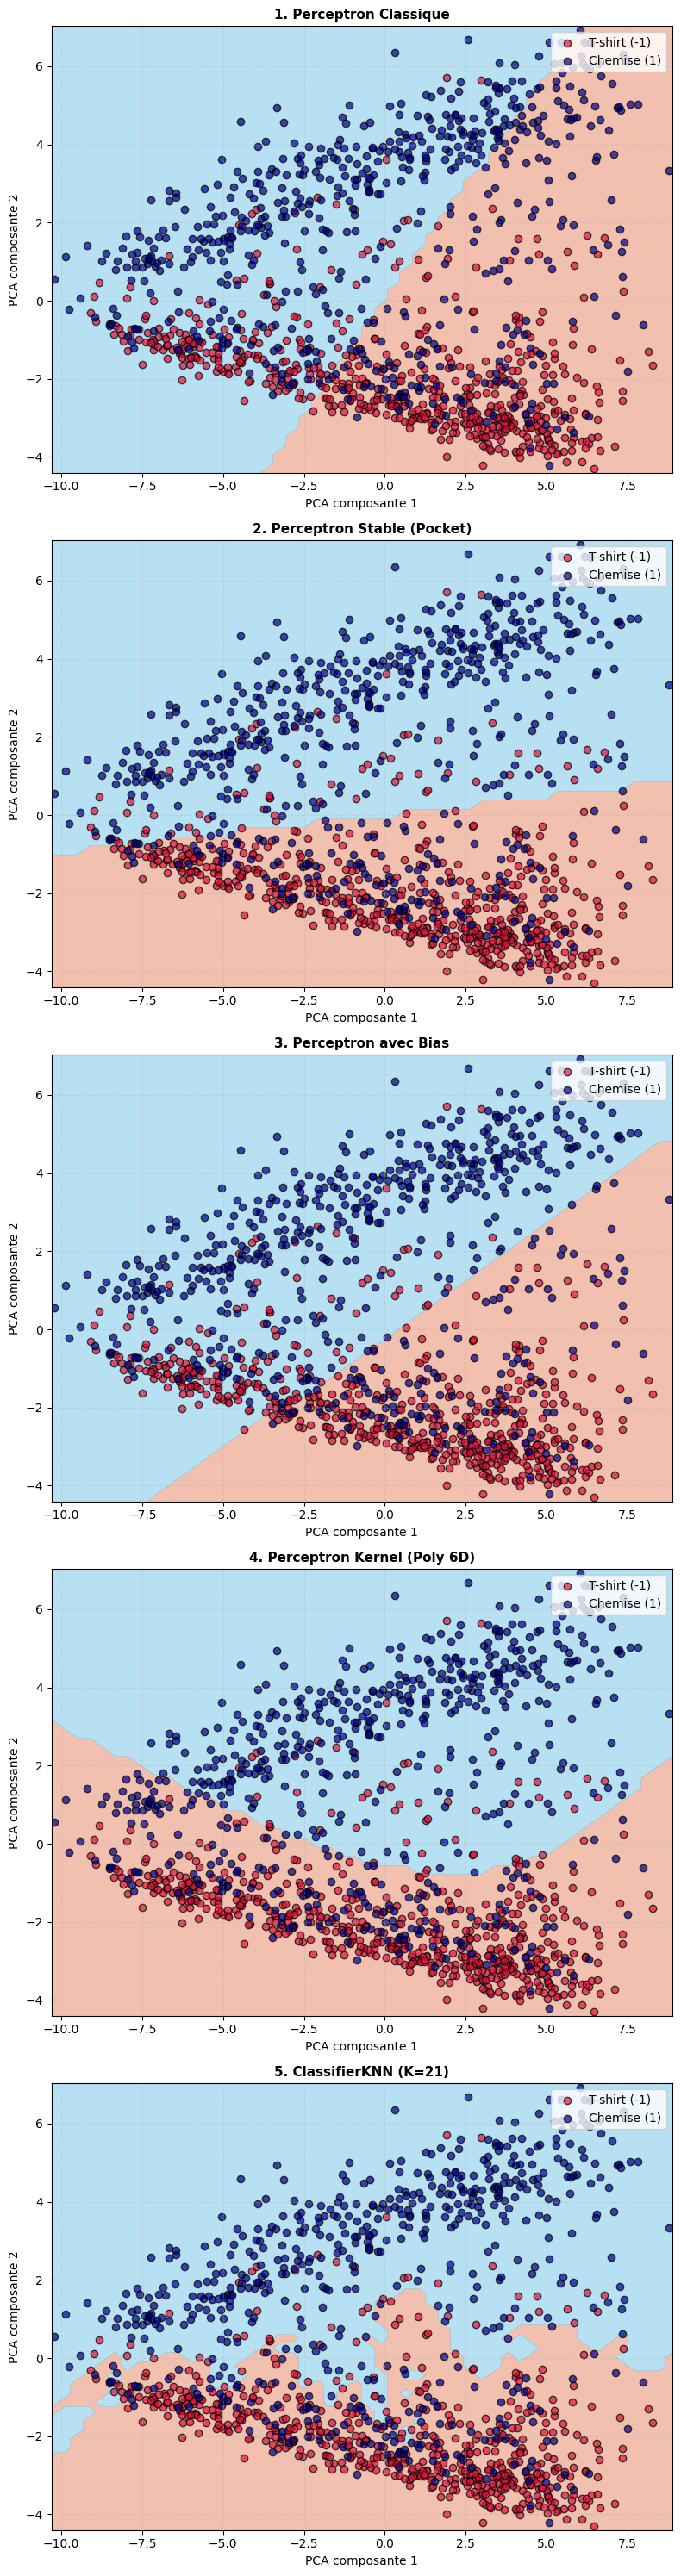

In [83]:
"""
CONCLUSION SUR CLASSIFIERS BINAIRES: visualisation verticale des 5 frontières
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)

pca = PCA(n_components=2, random_state=42)
X_2D = pca.fit_transform(DS_binaire[0])
Y_2D = DS_binaire[1]

X_2D_train = X_2D.astype(np.float64)
Y_2D_train = Y_2D.astype(np.int64)

n_features_2d = 2
learning_rate = 0.01
un_noyau = cl.KernelPoly()

p_classique_2d = cl.ClassifierPerceptron(n_features_2d, learning_rate, init=True)
p_stable_2d    = cl.ClassifierPerceptronStable(n_features_2d, learning_rate, init=True)
knn_2d         = cl.ClassifierKNN(n_features_2d, k=21)
p_bias         = cl.ClassifierPerceptronBias(n_features_2d, learning_rate, init=True)
p_kernel       = cl.ClassifierPerceptronKernel(n_features_2d, learning_rate, noyau=un_noyau, init=True)

p_classique_2d.train(X_2D_train, Y_2D_train)
p_stable_2d.train(X_2D_train, Y_2D_train)
knn_2d.train(X_2D_train, Y_2D_train)
p_bias.train(X_2D_train, Y_2D_train)
p_kernel.train(X_2D_train, Y_2D_train)

fig, axes = plt.subplots(5, 1, figsize=(8, 30))

classifiers = [
    (p_classique_2d, "1. Perceptron Classique"),
    (p_stable_2d,    "2. Perceptron Stable (Pocket)"),
    (p_bias,         "3. Perceptron avec Bias"),
    (p_kernel,       "4. Perceptron Kernel (Poly 6D)"),
    (knn_2d,         "5. ClassifierKNN (K=21)"),
]

for ax, (clf, title) in zip(axes, classifiers):
    plt.sca(ax)
    vis.visualiser_frontiere_2d(X_2D_train, Y_2D_train, clf, title=title)
    plt.xlabel("PCA composante 1")
    plt.ylabel("PCA composante 2")

plt.tight_layout()
plt.show()

Entraînement OAA avec Perceptron...
  Train: 80.52%  |  Test: 77.18%
Entraînement OAA avec Perceptron Stable...
  Train: 87.67%  |  Test: 83.08%
Entraînement OAA avec Perceptron Bias...
  Train: 85.26%  |  Test: 81.33%
Entraînement OAA avec KNN (k=21)...
  Train: 78.70%  |  Test: 80.00%


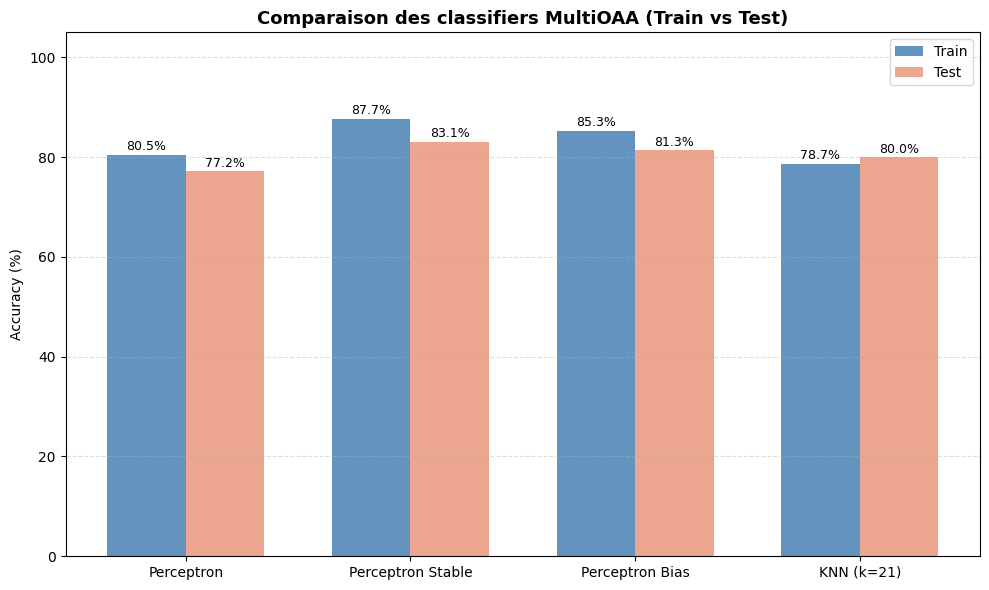

In [84]:
# TROISIEME ETAPE: Comparaison des classifiers multiclasse OAA
np.random.seed(42)

X_train_hom, Y_train_hom = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.4)
X_test_hom,  Y_test_hom  = ut.echantillonnage_homogene(X_test_raw,  Y_test_raw,  0.4)

# Маленький сэмпл специально для KNN
X_train_knn, Y_train_knn = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.05)
X_test_knn,  Y_test_knn  = ut.echantillonnage_homogene(X_test_raw,  Y_test_raw,  0.05)

v_dimension = X_train_hom.shape[1]

# --- Définition des classifiers de base ---
base_classifiers = {
    "Perceptron":        (cl.ClassifierPerceptron(v_dimension, learning_rate=0.01, init=True),
                          X_train_hom, Y_train_hom, X_test_hom, Y_test_hom),
    "Perceptron Stable": (cl.ClassifierPerceptronStable(v_dimension, learning_rate=0.01, init=True),
                          X_train_hom, Y_train_hom, X_test_hom, Y_test_hom),
    "Perceptron Bias":   (cl.ClassifierPerceptronBias(v_dimension, learning_rate=0.01, init=True),
                          X_train_hom, Y_train_hom, X_test_hom, Y_test_hom),
    "KNN (k=21)":        (cl.ClassifierKNN(v_dimension, k=21),
                          X_train_knn, Y_train_knn, X_test_knn, Y_test_knn),  # petit échantillon
}

results = {}

for name, (base_clf, X_tr, Y_tr, X_te, Y_te) in base_classifiers.items():
    print(f"Entraînement OAA avec {name}...")
    multi_clf = cl.ClassifierMultiOAA(v_dimension, base_clf)
    multi_clf.train(X_tr, Y_tr)
    
    train_acc = multi_clf.accuracy(X_tr, Y_tr)
    test_acc  = multi_clf.accuracy(X_te, Y_te)
    results[name] = {"train": train_acc, "test": test_acc}
    print(f"  Train: {train_acc*100:.2f}%  |  Test: {test_acc*100:.2f}%")

# --- Graphique comparatif ---
names      = list(results.keys())
train_accs = [results[n]["train"] * 100 for n in names]
test_accs  = [results[n]["test"]  * 100 for n in names]

x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_train = ax.bar(x - width/2, train_accs, width, label='Train', color='steelblue',  alpha=0.85)
bars_test  = ax.bar(x + width/2, test_accs,  width, label='Test',  color='darksalmon', alpha=0.85)

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=9)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=9)

ax.set_title("Comparaison des classifiers MultiOAA (Train vs Test)", fontsize=13, fontweight='bold')
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


MATRICE DE CONFUSION : MULTICLASSE — Perceptron
[0 1 2 3 4 5 6 7 8 9]


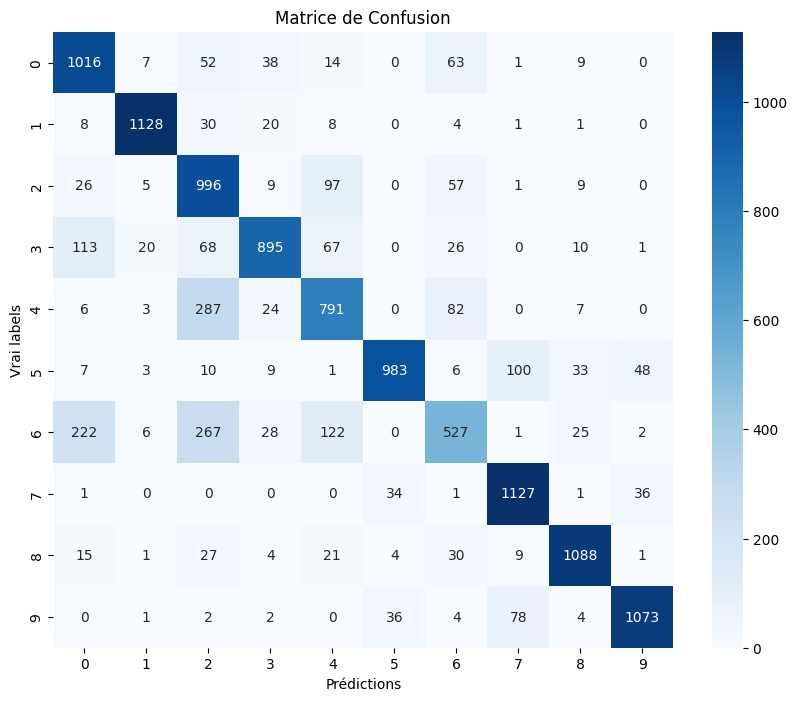

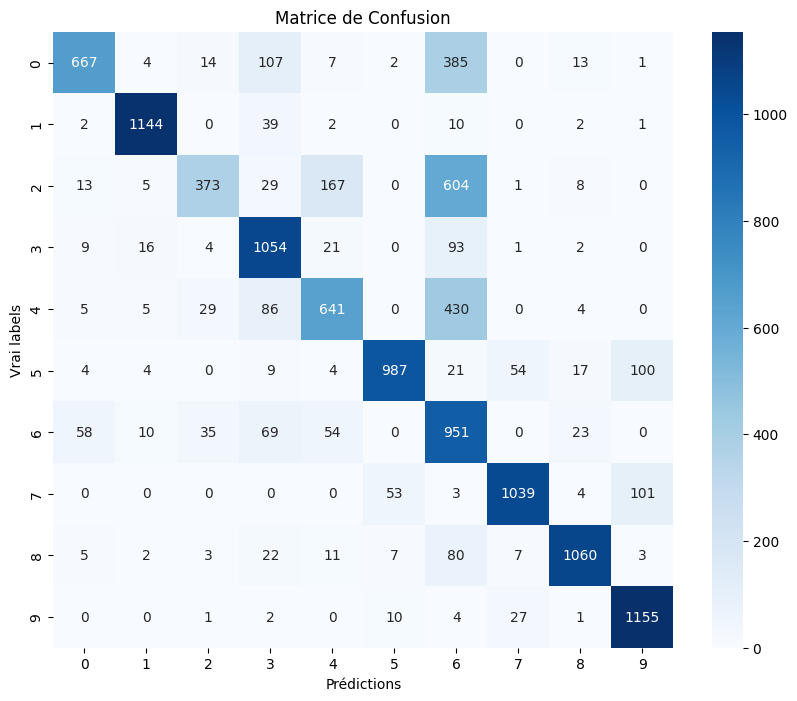

MATRICE DE CONFUSION : MULTICLASSE — Perceptron Stable
[0 1 2 3 4 5 6 7 8 9]


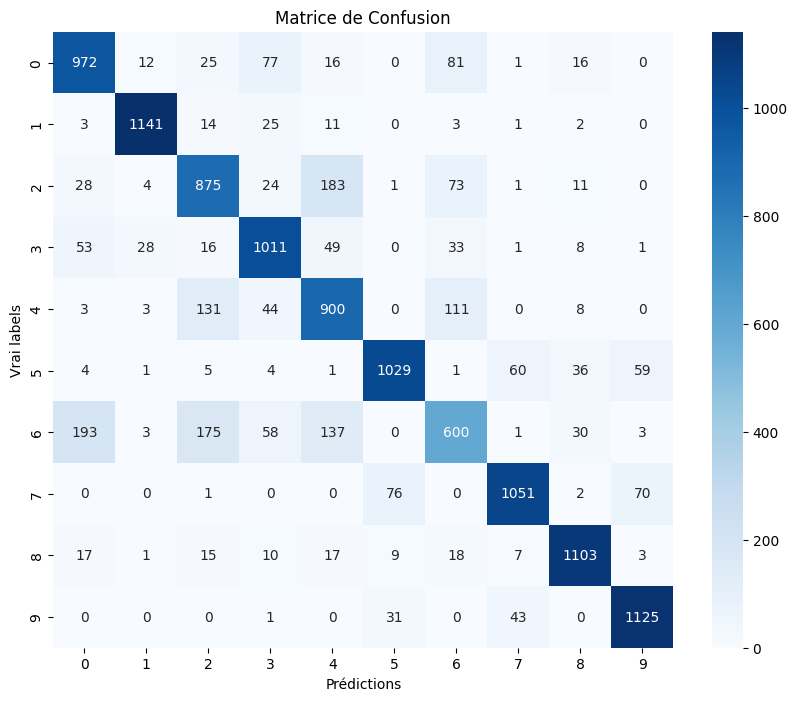

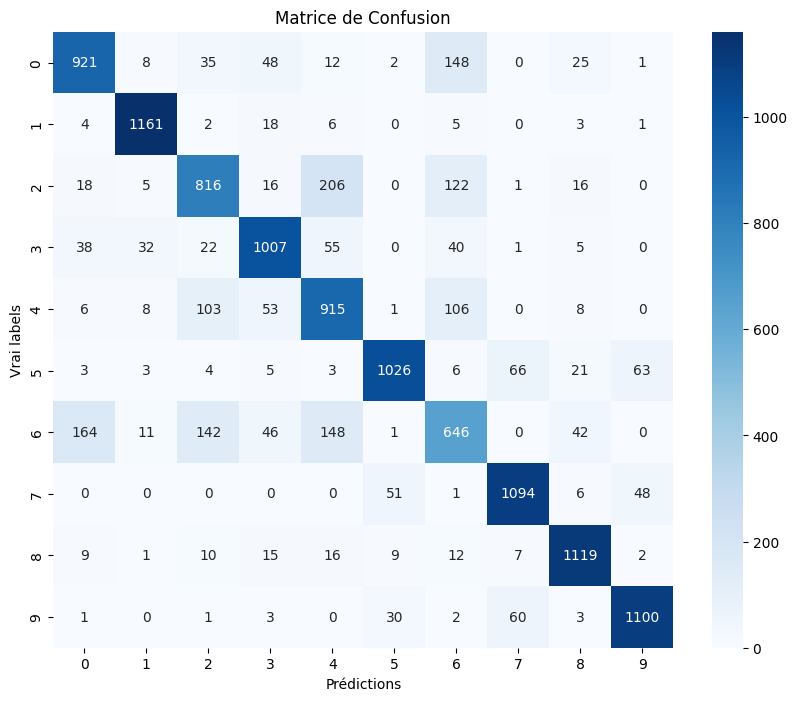

MATRICE DE CONFUSION : MULTICLASSE — Perceptron Bias
[0 1 2 3 4 5 6 7 8 9]


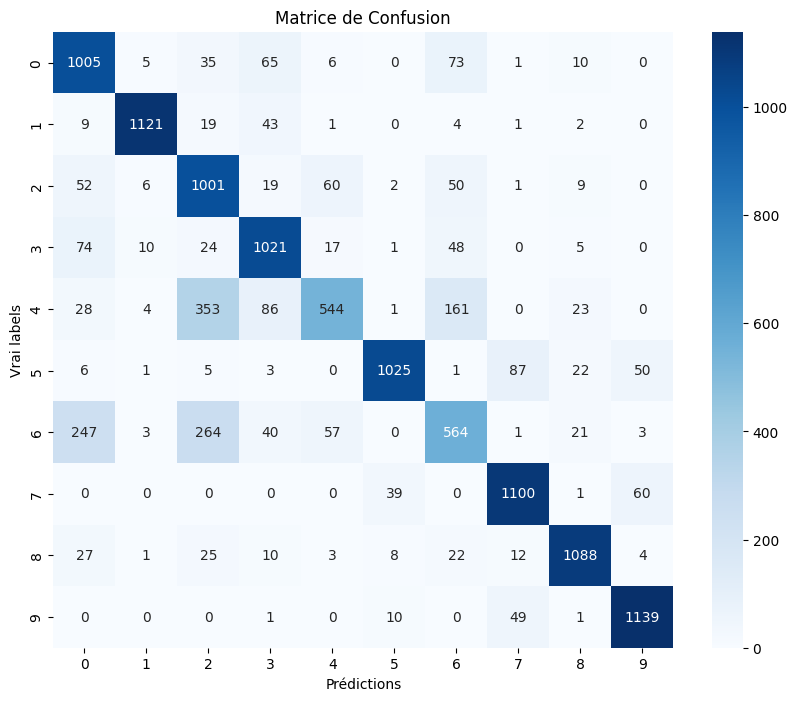

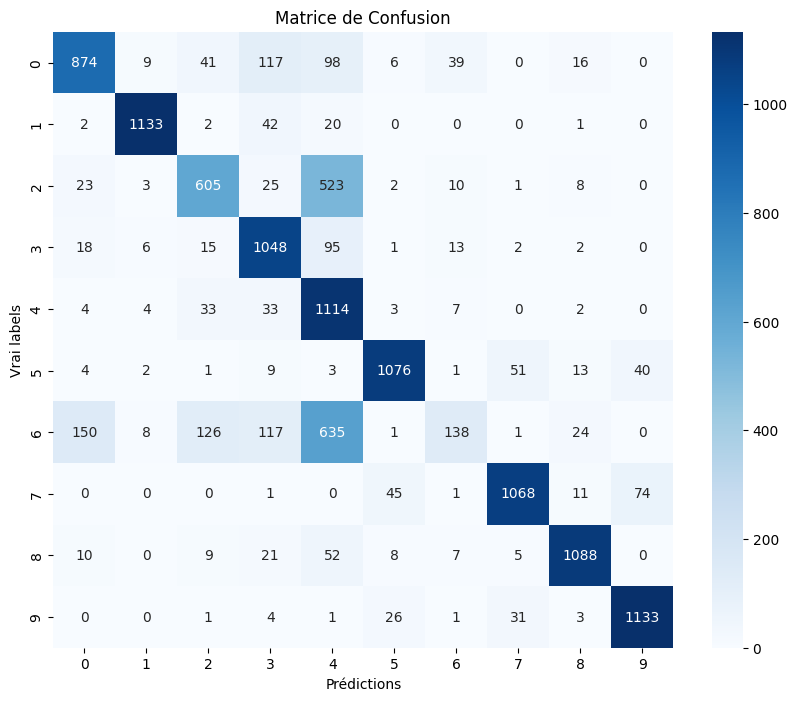

MATRICE DE CONFUSION : MULTICLASSE — KNN (k=21)
[0 1 2 3 4 5 6 7 8 9]


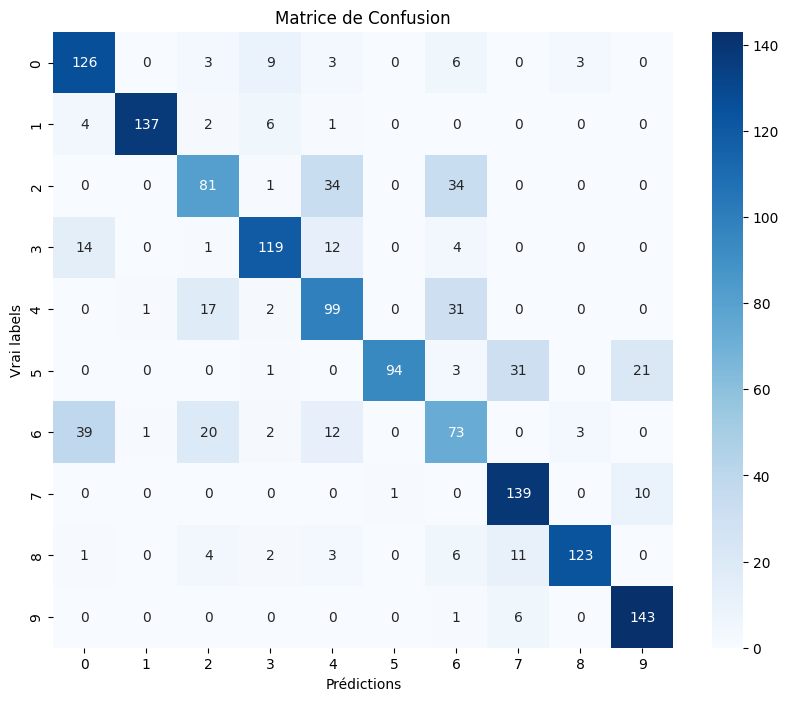

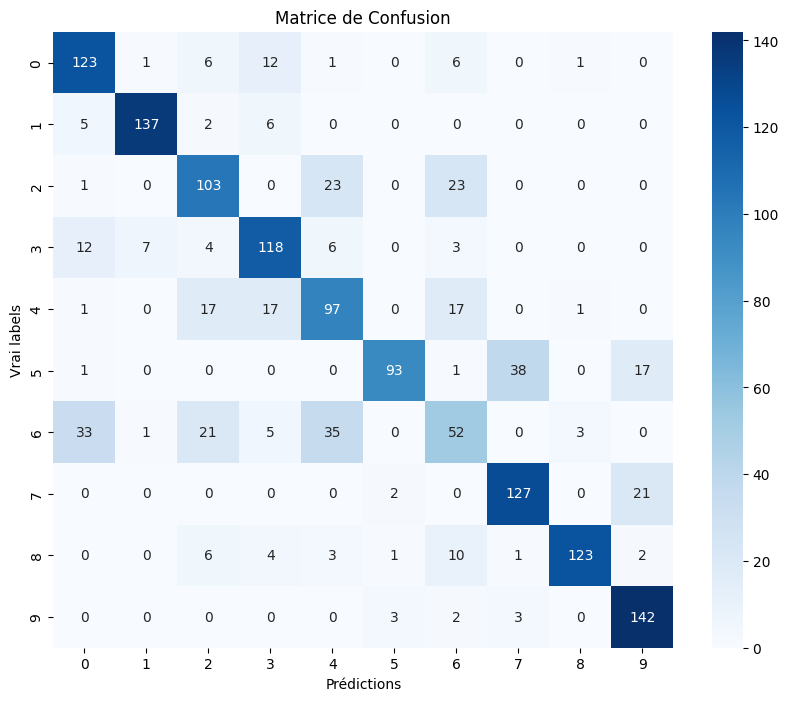

In [85]:
# TROISIEME ETAPE: Classifier multiclasse - comparaison via matrices de confusion
np.random.seed(42)

X_train_hom, Y_train_hom = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.4)
X_train_knn, Y_train_knn = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.05)

DS_eval     = (X_train_hom, Y_train_hom)
DS_eval_knn = (X_train_knn, Y_train_knn)

v_dimension = X_train_hom.shape[1]

base_classifiers = {
    "Perceptron":        (cl.ClassifierPerceptron(v_dimension, learning_rate=0.01, init=True),        DS_eval),
    "Perceptron Stable": (cl.ClassifierPerceptronStable(v_dimension, learning_rate=0.01, init=True),  DS_eval),
    "Perceptron Bias":   (cl.ClassifierPerceptronBias(v_dimension, learning_rate=0.01, init=True),    DS_eval),
    "KNN (k=21)":        (cl.ClassifierKNN(v_dimension, k=21),                                        DS_eval_knn),
}

for name, (base_clf, DS) in base_classifiers.items():
    print("="*60)
    print(f"MATRICE DE CONFUSION : MULTICLASSE — {name}")
    print("="*60)
    multi_clf = cl.ClassifierMultiOAA(v_dimension, base_clf)
    ev.matrice_de_confusion(multi_clf, DS, nb_iter=2, stratified=True)

VALIDATION CROISÉE MULTICLASSE — Perceptron
Accuracy Moyenne : 78.65%
Écart-type       : 1.6631
VALIDATION CROISÉE MULTICLASSE — Perceptron Stable
Accuracy Moyenne : 82.31%
Écart-type       : 0.5094
VALIDATION CROISÉE MULTICLASSE — Perceptron Bias
Accuracy Moyenne : 80.32%
Écart-type       : 1.8389
VALIDATION CROISÉE MULTICLASSE — KNN (k=21)
Accuracy Moyenne : 76.57%
Écart-type       : 1.1010


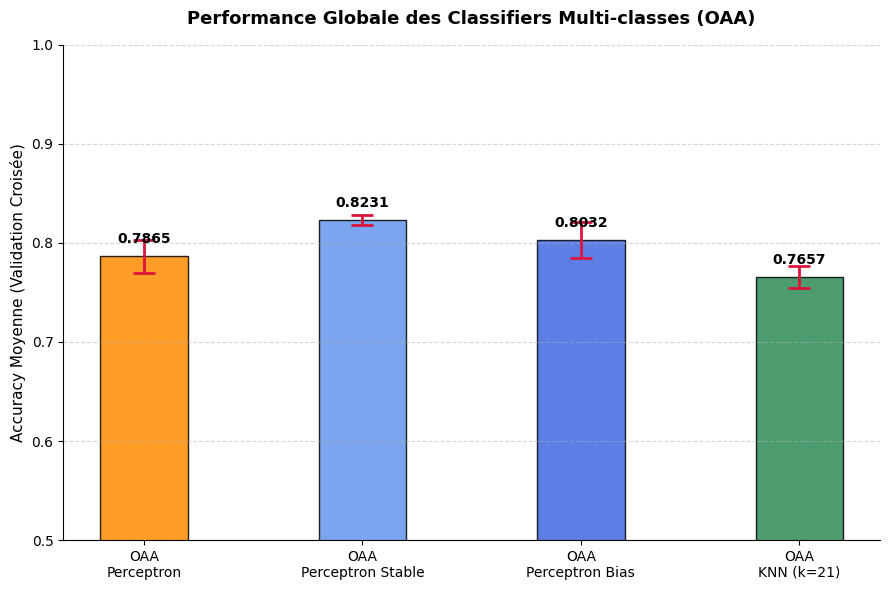

In [86]:
# TROISIEME ETAPE: Classifier multiclasse - validation croisée comparaison tous classifiers
np.random.seed(42)

X_train_hom, Y_train_hom = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.4)
X_train_knn, Y_train_knn = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.05)

DS_eval     = (X_train_hom, Y_train_hom)
DS_eval_knn = (X_train_knn, Y_train_knn)

v_dimension = X_train_hom.shape[1]

base_classifiers = {
    "Perceptron":        (cl.ClassifierPerceptron(v_dimension, learning_rate=0.01, init=True),       DS_eval),
    "Perceptron Stable": (cl.ClassifierPerceptronStable(v_dimension, learning_rate=0.01, init=True), DS_eval),
    "Perceptron Bias":   (cl.ClassifierPerceptronBias(v_dimension, learning_rate=0.01, init=True),   DS_eval),
    "KNN (k=21)":        (cl.ClassifierKNN(v_dimension, k=21),                                       DS_eval_knn),
}

noms         = []
moyennes     = []
ecarts_types = []

for name, (base_clf, DS) in base_classifiers.items():
    print("="*60)
    print(f"VALIDATION CROISÉE MULTICLASSE — {name}")
    print("="*60)
    multi_clf = cl.ClassifierMultiOAA(v_dimension, base_clf)
    _, moy, std = ev.validation_croisee(multi_clf, DS, nb_iter=4, stratified=True)
    
    noms.append(f"OAA\n{name}")
    moyennes.append(moy)
    ecarts_types.append(std)
    
    print(f"Accuracy Moyenne : {moy * 100:.2f}%")
    print(f"Écart-type       : {std * 100:.4f}")

vis.plot_comparaison_classifiers(noms, moyennes, ecarts_types,
                                 title="Performance Globale des Classifiers Multi-classes (OAA)")

### IV. Les Arbres de Décision : Une Approche Non-Linéaire

Pour pallier les limites géométriques des modèles linéaires, qui se sont avérés insuffisants pour capturer la complexité globale de Fashion MNIST, nous introduisons la paradigme des **Arbres de Décision**. Ce modèle non-paramétrique repose sur une stratégie de partitionnement récurrent de l'espace des descripteurs, en effectuant des coupures successives et orthogonales aux axes de coordonnées. Contrairement au Perceptron qui ajuste des poids globaux, l'arbre de décision isole localement des régions de pixels de plus en plus homogènes en optimisant à chaque étape un critère statistique d'hétérogénéité, formalisé par l'**Entropie de Shannon** et le **Gain d'Information**.

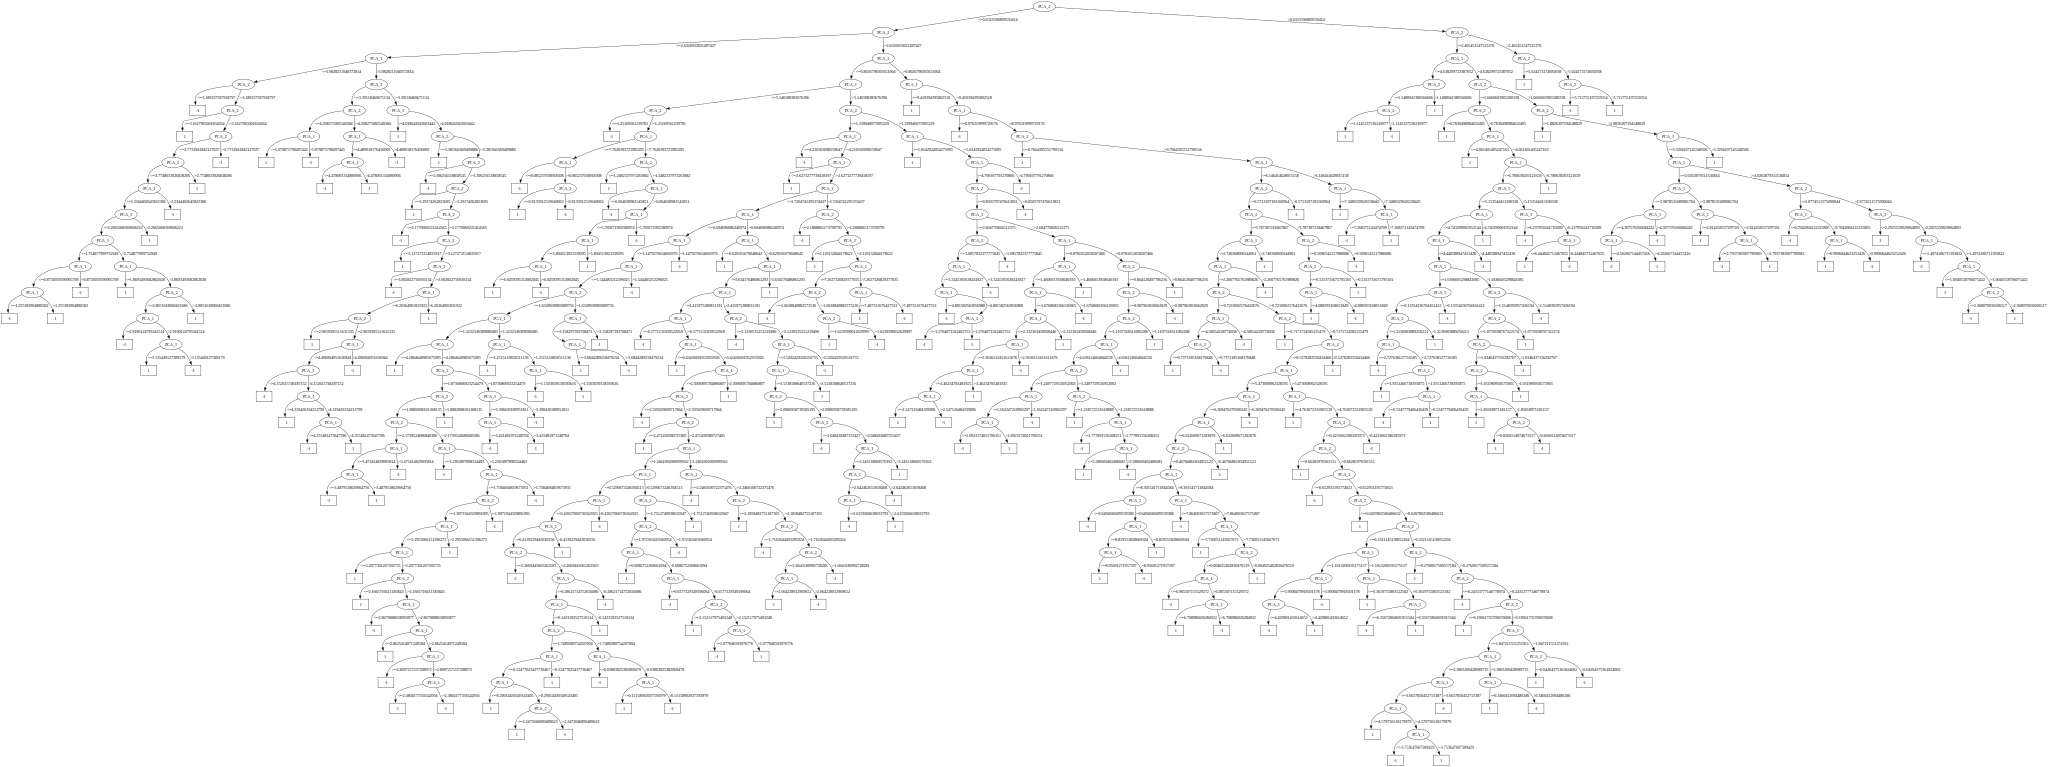

In [45]:
np.random.seed(42)

X_b = DS_binaire[0]
Y_b = DS_binaire[1]

pca_tree = PCA(n_components=2)
X_b_pca = pca_tree.fit_transform(X_b)

arbre_visu = ar.ClassifierArbreNumerique(input_dimension=2, epsilon=0.1, LNoms=['PCA_1', 'PCA_2'])
arbre_visu.train(X_b_pca, Y_b)

g_tree = gv.Digraph('Arbre_Decision', format='png')
arbre_visu.affiche(g_tree)

g_tree.render('arbre_structure', view=False)
g_tree

### Analyse Visuelle de l'Arbre de Décision Numérique

La visualisation du graphe généré par `ClassifierArbreNumerique` permet de mettre en évidence plusieurs propriétés fondamentales de ce modèle :

1. **Complexité structurelle (Profondeur élevée) :** Bien qu'il soit entraîné dans un espace réduit (PCA 2D), l'arbre se développe de manière très dense avec une multitude de niveaux de décision. Cela démontre sa capacité intrinsèque à sur-diviser l'espace pour isoler le moindre bruit ou point atypique.
2. **Coupures orthogonales successives :** Chaque nœud ovale représente un test binaire strict sur l'une des composantes (ex: $x_1 \le seuil$). Les feuilles rectangulaires terminales affichent la classe majoritaire prédite.

**Observation critique :** Cette ramification extrême est le symptôme visuel parfait d'une forte tendance au **sur-apprentissage (overfitting)**. L'arbre ne généralise pas la forme globale, il mémorise géométriquement la position de chaque exemple d'entraînement.

In [47]:
np.random.seed(42)
X_train_tree, Y_train_tree = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, 0.01) 
X_test_tree, Y_test_tree = ut.echantillonnage_homogene(X_test_raw, Y_test_raw, 0.01)

v_dimension = X_train_tree.shape[1]

arbre_complet = ar.ClassifierArbreNumerique(input_dimension=v_dimension, epsilon=0.0)

print("Entraînement de l'arbre complet sur les pixels originaux (veuillez patienter)...")
arbre_complet.train(X_train_tree, Y_train_tree)

acc_train = arbre_complet.accuracy(X_train_tree, Y_train_tree)
acc_test = arbre_complet.accuracy(X_test_tree, Y_test_tree)
nb_feuilles = arbre_complet.number_leaves()

print("="*50)
print(f"Nombre total de feuilles : {nb_feuilles}")
print(f"Accuracy sur Train       : {acc_train * 100:.2f}%")
print(f"Accuracy sur Test        : {acc_test * 100:.2f}%")
print("="*50)

Entraînement de l'arbre complet sur les pixels originaux (veuillez patienter)...
Nombre total de feuilles : 76
Accuracy sur Train       : 100.00%
Accuracy sur Test        : 65.00%


### Analyse des Performances de l'Arbre de Décision Unique

Les résultats numériques confirment quantitativement le phénomène de **sur-apprentissage (overfitting)** propre aux arbres de décision non contraints :

1. **Mémorisation parfaite du Train ($100\%$) :** L'arbre s'est développé jusqu'à obtenir des feuilles totalement pures (entropie nulle), ce qui signifie qu'il a créé des règles d'exclusion sur mesure pour chaque pixel du jeu d'entraînement.
2. **Faible généralisation sur le Test ($65\%$) :** La chute brutale de l'accuracy montre que les critères géométriques rigides trouvés par l'arbre (coupures orthogonales sur des pixels isolés) capturent le bruit des images plutôt que des concepts morphologiques globaux.

**Conclusion :** Un arbre de décision unique possède une variance trop élevée pour être performant sur un dataset complexe comme Fashion MNIST. Pour stabiliser les frontières et réduire cette variance sans perdre en pouvoir non-linéaire, il est indispensable d'introduire la méthode d'ensemble : les **Forêts Aléatoires (Random Forests)**.

### V. Extension vers les Forêts Aléatoires : Bagging et Évaluation OOB

Pour corriger la forte variance de l'arbre de décision unique, nous implémentons l'algorithme du **Bagging** (*Bootstrap Aggregating*). Cette méthode d'ensemble consiste à entraîner plusieurs arbres indépendants sur des sous-ensembles de données générés par tirage aléatoire avec remplacement (*bootstrap*). La prédiction finale est obtenue par un vote de majorité.

En parallèle, nous exploitons la propriété des exemples **OOB** (*Out-Of-Bag*). Lors de chaque tirage de bootstrap, environ $36.8\%$ des données sont laissées de côté pour chaque arbre. Ces données non vues servent de jeu de validation interne "gratuit", permettant d'estimer l'erreur de généralisation du modèle (le score OOB) sans avoir recours à un jeu de test indépendant.